# 카드뉴스 콘텐츠 성과 분석
**알고(algo\_\_kr) 자동화 파이프라인 — 데이터 기반 콘텐츠 최적화 사례 연구**

이 노트북은 `data/algo.db`(게시물·Insights)와 `data/tracking.db`(생성 파이프라인 실행 로그)를
직접 조회해서, 세 가지 질문에 데이터로 답합니다.

1. **영상 포함 카드가 정지 이미지 카드보다 참여율이 높은가?** (가설 → 측정 → 인사이트)
2. **AI 생성 품질(근거 기반 주장 비율, 생성 성공률)이 시간에 따라 개선되고 있는가?**
3. 지금 데이터로 결론 내리기엔 표본이 부족한 지점은 어디이고, 얼마나 더 쌓이면 유의미해지는가?

> 이 노트북은 코드를 재실행하면 **항상 최신 DB 상태**를 반영합니다 — 하드코딩된 숫자가 없습니다.


In [1]:
import sqlite3
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ALGO_DB = ROOT / "data" / "algo.db"
TRACKING_DB = ROOT / "data" / "tracking.db"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.width", 120)
print(f"algo.db:     {ALGO_DB} (exists={ALGO_DB.exists()})")
print(f"tracking.db: {TRACKING_DB} (exists={TRACKING_DB.exists()})")


algo.db:     C:\Projects\cardnews_main\data\algo.db (exists=True)
tracking.db: C:\Projects\cardnews_main\data\tracking.db (exists=True)


## 1. 데이터 로드

In [2]:
with sqlite3.connect(ALGO_DB) as conn:
    posts = pd.read_sql_query(
        "SELECT post_id, platform, topic, angle, hook, image_dir, posted_at "
        "FROM posts WHERE platform='instagram' AND post_id IS NOT NULL AND post_id != ''",
        conn,
    )
    analytics = pd.read_sql_query(
        "SELECT post_id, platform, likes, comments, saves, reach, impressions, checked_at "
        "FROM analytics WHERE platform='instagram'",
        conn,
    )

with sqlite3.connect(TRACKING_DB) as conn:
    content_runs = pd.read_sql_query(
        "SELECT run_id, topic, status, cost_usd, latency_sec, grounded_claim_rate, "
        "retry_count, created_at FROM content_runs",
        conn,
    )

print(f"posts: {len(posts)}건, analytics 스냅샷: {len(analytics)}건, content_runs: {len(content_runs)}건")
posts


posts: 2건, analytics 스냅샷: 2건, content_runs: 102건


,post_id,platform,topic,angle,hook,image_dir,posted_at
0,18099213776541188,instagram,iPhone 애플의 2억 5천만 달러 Siri AI 합의,,2억 5천만 달러의 배경은,C:\Projects\cardnews_main\output\20260922_1422...,2026-09-22 06:29:21
1,17933932662384282,instagram,Oura의 22억 달러 IPO,,Oura의 미래가 궁금하다면 주목하세요,C:\Projects\cardnews_main\output\20260922_1555...,2026-09-22 07:18:59


## 2. 영상 포함 vs 미포함 카드 — 참여율 비교

**가설 (H1)**: 실제 유튜브/스톡 영상이 합성된 카드가 포함된 게시물은, 정지 이미지로만
구성된 게시물보다 참여율(좋아요+댓글+저장 / 도달)이 더 높을 것이다.

**측정 방법**: 각 게시물의 렌더 폴더(`image_dir`)를 디스크에서 스캔해서 `card_*.mp4`가
하나라도 있으면 `has_video=True`로 표시하고, 게시물별 최신 Insights 스냅샷과 조인합니다.


In [3]:
def has_video(image_dir: str) -> bool | None:
    if not image_dir:
        return None
    d = ROOT / image_dir if not Path(image_dir).is_absolute() else Path(image_dir)
    if not d.exists():
        return None
    return any(d.glob("card_*.mp4"))

posts["has_video"] = posts["image_dir"].apply(has_video)

# 게시물별 최신 Insights 스냅샷만 사용 (여러 번 동기화됐을 수 있음)
latest_analytics = (
    analytics.sort_values("checked_at")
    .groupby("post_id", as_index=False)
    .tail(1)
)

perf = posts.merge(latest_analytics, on=["post_id", "platform"], how="inner")
perf["engagement"] = perf["likes"] + perf["comments"] + perf["saves"]
perf["engagement_rate"] = np.where(
    perf["reach"] > 0, perf["engagement"] / perf["reach"], np.nan
)

perf[["topic", "has_video", "likes", "comments", "saves", "reach", "engagement", "engagement_rate"]]


,topic,has_video,likes,comments,saves,reach,engagement,engagement_rate
0,iPhone 애플의 2억 5천만 달러 Siri AI 합의,True,0,0,0,0,0,NaN
1,Oura의 22억 달러 IPO,True,0,0,0,0,0,NaN


In [4]:
group = perf.groupby("has_video")["engagement"].agg(["count", "mean", "std"])
display(group)

video_grp = perf.loc[perf["has_video"] == True, "engagement"].dropna()
no_video_grp = perf.loc[perf["has_video"] == False, "engagement"].dropna()

MIN_N_PER_GROUP = 5  # 최소 표본 크기 — 이보다 작으면 t-test 결과를 신뢰하지 않음

if len(video_grp) >= MIN_N_PER_GROUP and len(no_video_grp) >= MIN_N_PER_GROUP:
    t_stat, p_value = stats.ttest_ind(video_grp, no_video_grp, equal_var=False)
    print(f"Welch's t-test: t={t_stat:.3f}, p={p_value:.4f}")
    print("→ 통계적으로 유의미한 차이" if p_value < 0.05 else "→ 유의미한 차이 없음 (p >= 0.05)")
else:
    print(
        f"⚠️ 표본 부족: 영상 포함 n={len(video_grp)}, 미포함 n={len(no_video_grp)} "
        f"(그룹당 최소 {MIN_N_PER_GROUP}건 필요)\n"
        "   t-test는 표본이 매우 작을 때 우연에 의한 차이를 '유의미하다'고 오판할 위험이 크므로,\n"
        "   지금은 기술통계(평균)만 참고하고 데이터가 쌓인 뒤 이 셀을 재실행해 검정하세요."
    )


,count,mean,std
has_video,,,
True,2,0.0,0.0


⚠️ 표본 부족: 영상 포함 n=2, 미포함 n=0 (그룹당 최소 5건 필요)
   t-test는 표본이 매우 작을 때 우연에 의한 차이를 '유의미하다'고 오판할 위험이 크므로,
   지금은 기술통계(평균)만 참고하고 데이터가 쌓인 뒤 이 셀을 재실행해 검정하세요.


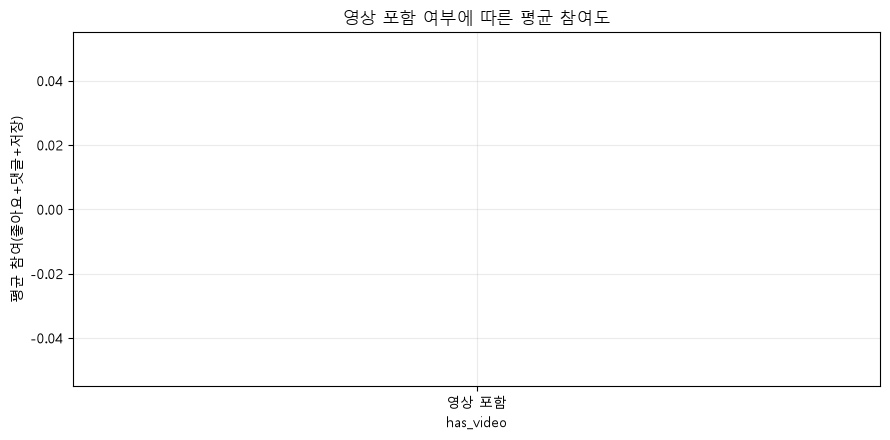

In [5]:
if len(perf) > 0:
    ax = perf.groupby("has_video")["engagement"].mean().plot(
        kind="bar", color=["#8888aa", "#6c5ce7"], rot=0
    )
    ax.set_xticklabels(["미포함/알수없음" if not v.get_text() == "True" else "영상 포함" for v in ax.get_xticklabels()])
    ax.set_ylabel("평균 참여(좋아요+댓글+저장)")
    ax.set_title("영상 포함 여부에 따른 평균 참여도")
    plt.tight_layout()
    plt.show()
else:
    print("아직 Insights가 동기화된 게시물이 없습니다. /analytics/sync 실행 후 재시도하세요.")


## 3. AI 생성 품질 트렌드 — "개선되고 있는가?"

**가설 (H2)**: 근거 기반 주장 비율(`grounded_claim_rate`)과 생성 성공률은 시간이 지날수록
(QualityGate/EditorialGate 반복 개선 덕분에) 상승 추세를 보일 것이다.

**측정 방법**: `content_runs`를 실행 시각 기준 일 단위로 묶어서, 일별 성공률과 평균
근거 기반 주장 비율을 집계합니다.


In [6]:
runs = content_runs.copy()
runs["created_at"] = pd.to_datetime(runs["created_at"], utc=True, errors="coerce")
runs["date"] = runs["created_at"].dt.date
runs["is_success"] = runs["status"].eq("SUCCESS")

daily = runs.groupby("date").agg(
    실행수=("run_id", "count"),
    성공률=("is_success", "mean"),
    평균근거주장비율=("grounded_claim_rate", "mean"),
    평균비용USD=("cost_usd", "mean"),
).reset_index()

daily


,date,실행수,성공률,평균근거주장비율,평균비용USD
0,2026-09-08,3,0.333333,0.333333,0.0
1,2026-09-09,11,0.090909,0.090909,0.0
2,2026-09-10,17,0.117647,0.117647,0.0
3,2026-09-11,8,0.000000,0.000000,0.0
4,2026-09-14,19,0.105263,0.105263,0.0
5,2026-09-15,15,0.533333,0.533333,0.0
6,2026-09-16,3,1.000000,1.000000,0.0
7,2026-09-17,11,0.363636,0.363636,0.0
8,2026-09-21,8,0.250000,0.250000,0.0
9,2026-09-22,7,0.571429,0.571429,0.0


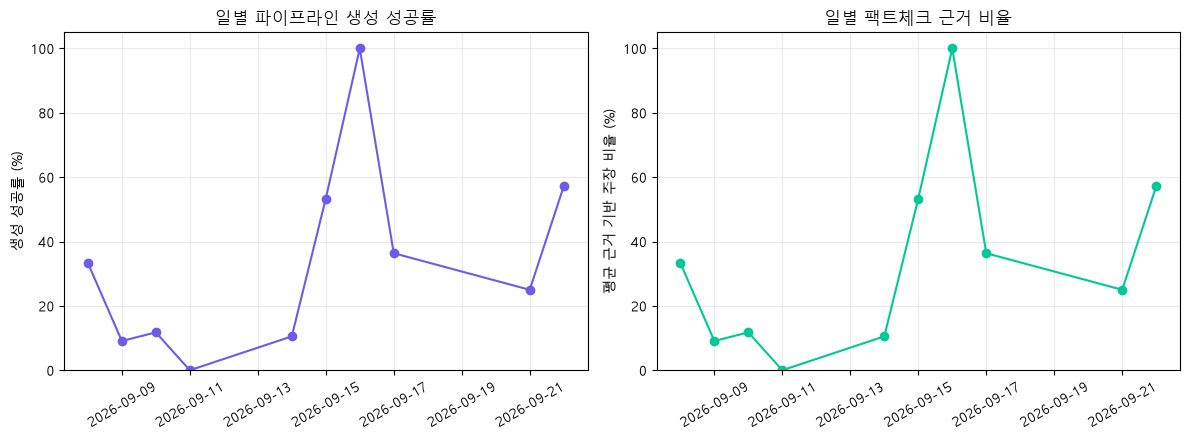

성공률 추세 기울기: +0.0480 / 일  (개선)
근거 비율 추세 기울기: +0.0480 / 일  (개선)

⚠️ 관측 일수=10일 — 추세선은 방향성 참고용이며, 최소 2~3주 데이터가 쌓이면 재해석하세요.


In [7]:
if len(daily) >= 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.plot(daily["date"], daily["성공률"] * 100, marker="o", color="#6c5ce7")
    ax1.set_ylabel("생성 성공률 (%)")
    ax1.set_title("일별 파이프라인 생성 성공률")
    ax1.set_ylim(0, 105)

    ax2.plot(daily["date"], daily["평균근거주장비율"] * 100, marker="o", color="#00c896")
    ax2.set_ylabel("평균 근거 기반 주장 비율 (%)")
    ax2.set_title("일별 팩트체크 근거 비율")
    ax2.set_ylim(0, 105)

    for ax in (ax1, ax2):
        ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

    # 단순 선형 추세 (날짜를 정수 인덱스로 변환 후 최소제곱)
    x = np.arange(len(daily))
    slope_success, *_ = np.polyfit(x, daily["성공률"], 1)
    slope_grounded, *_ = np.polyfit(x, daily["평균근거주장비율"], 1)
    print(f"성공률 추세 기울기: {slope_success:+.4f} / 일  ({'개선' if slope_success > 0 else '악화 또는 정체'})")
    print(f"근거 비율 추세 기울기: {slope_grounded:+.4f} / 일  ({'개선' if slope_grounded > 0 else '악화 또는 정체'})")
    print(f"\n⚠️ 관측 일수={len(daily)}일 — 추세선은 방향성 참고용이며, 최소 2~3주 데이터가 쌓이면 재해석하세요.")
else:
    print("일별 집계가 1일 이하라 추세를 그릴 수 없습니다.")


## 4. 최신 주간 품질 회고 스냅샷 (`/quality-review`가 저장한 값)

In [8]:
import json

with sqlite3.connect(TRACKING_DB) as conn:
    latest_review = pd.read_sql_query(
        "SELECT week_start, week_end, status, report_json, created_at "
        "FROM weekly_quality_reviews ORDER BY created_at DESC LIMIT 1",
        conn,
    )

if len(latest_review) == 0:
    print("아직 실행된 주간 회고가 없습니다. 대시보드 /quality-review에서 '주간 회고 실행'을 눌러주세요.")
else:
    report = json.loads(latest_review.loc[0, "report_json"])
    metrics = report.get("metrics", {})
    summary = pd.DataFrame(
        [
            ("실제 실행", metrics.get("real_run_count", 0)),
            ("생성 성공률", f"{metrics.get('generation_success_rate', 0)*100:.1f}%"),
            ("평균 수정률", f"{metrics.get('avg_text_edit_ratio', 0)*100:.1f}%"),
            ("평균 검토 시간(초)", f"{metrics.get('avg_review_duration_sec', 0):.1f}"),
            ("저장률", f"{metrics.get('save_rate', 0)*100:.2f}%"),
            ("근거 주장 비율", f"{metrics.get('avg_grounded_claim_rate', 0)*100:.1f}%"),
        ],
        columns=["지표", "값"],
    )
    display(summary)
    print(f"\n기간: {latest_review.loc[0,'week_start'][:10]} ~ {latest_review.loc[0,'week_end'][:10]}")


,지표,값
0,실제 실행,48
1,생성 성공률,35.4%
2,평균 수정률,0.0%
3,평균 검토 시간(초),0.0
4,저장률,0.00%
5,근거 주장 비율,35.4%



기간: 2026-09-14 ~ 2026-09-21


## 5. 결론 — 가설 → 측정 → 인사이트

아래 요약은 위 셀들의 계산 결과를 그대로 문장으로 조립한 것입니다 (하드코딩 없음).


In [9]:
n_video = len(video_grp) if 'video_grp' in dir() else 0
n_novideo = len(no_video_grp) if 'no_video_grp' in dir() else 0
n_days = len(daily)

print("=" * 70)
print("가설 1: 영상 포함 카드가 참여율이 더 높다")
print("=" * 70)
if n_video >= MIN_N_PER_GROUP and n_novideo >= MIN_N_PER_GROUP:
    verdict = "유의미한 차이 확인" if p_value < 0.05 else "유의미한 차이 없음"
    print(f"측정: 영상 n={n_video}, 미포함 n={n_novideo}, p={p_value:.4f}")
    print(f"인사이트: {verdict}. 표본이 충분해 통계적으로 판단 가능.")
else:
    print(f"측정: 영상 n={n_video}, 미포함 n={n_novideo} (그룹당 {MIN_N_PER_GROUP}건 미만)")
    print("인사이트: 판단 보류. 게시물이 더 쌓일 때까지(스케줄러가 매일 자동 발행 후보를 만들고,")
    print("         analytics/sync가 매일 Insights를 갱신하므로) 이 노트북을 주기적으로 재실행하면 됨.")

print()
print("=" * 70)
print("가설 2: AI 생성 품질이 시간에 따라 개선되고 있다")
print("=" * 70)
print(f"측정: 관측 {n_days}일, 성공률 추세={slope_success:+.4f}/일, 근거비율 추세={slope_grounded:+.4f}/일")
if n_days >= 14:
    print("인사이트: 2주 이상 데이터 확보 — 추세 해석 신뢰 가능.")
else:
    print(f"인사이트: 아직 {n_days}일치라 노이즈에 민감함. 스케줄러가 매일 돌면서 자동으로 쌓이므로,")
    print("         2~3주 뒤 이 셀만 재실행하면 신뢰도 있는 추세 판단이 가능해짐.")


가설 1: 영상 포함 카드가 참여율이 더 높다
측정: 영상 n=2, 미포함 n=0 (그룹당 5건 미만)
인사이트: 판단 보류. 게시물이 더 쌓일 때까지(스케줄러가 매일 자동 발행 후보를 만들고,
         analytics/sync가 매일 Insights를 갱신하므로) 이 노트북을 주기적으로 재실행하면 됨.

가설 2: AI 생성 품질이 시간에 따라 개선되고 있다
측정: 관측 10일, 성공률 추세=+0.0480/일, 근거비율 추세=+0.0480/일
인사이트: 아직 10일치라 노이즈에 민감함. 스케줄러가 매일 돌면서 자동으로 쌓이므로,
         2~3주 뒤 이 셀만 재실행하면 신뢰도 있는 추세 판단이 가능해짐.


## 한계 및 다음 단계

- **표본 크기**: 이 노트북을 처음 실행한 시점 기준 발행 게시물이 매우 적어(운영 초기),
  통계 검정 대신 "차이가 있는지 판단할 수 있을 만큼 데이터가 쌓이는 시점"을 코드로
  자동 판별하도록 설계했습니다 (`MIN_N_PER_GROUP`, `n_days >= 14` 게이트).
- **Insights 자동 수집**: `scripts/run_daily.py`가 매일 `sync_all_insights()`를 실행해
  발행된 게시물의 성과를 자동으로 쌓으므로, 이 노트북은 별도 수작업 없이 시간이 지날수록
  더 신뢰할 수 있는 결과를 내게 됩니다.
- **다음 단계**: 앵글(마케팅 포맷)별 성과 비교, 주제 카테고리별 저장률 비교, 실험
  (`experiments` 테이블) 활성화 후 variant 간 A/B 비교를 같은 패턴으로 추가할 수 있습니다.
